## Create Analytical Approximation
Goal: Creation of an analytical solution to a system of 11 (?) ordinary differential equations representing the female endocrine cycle

In [9]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

Define auxiliary functions to account for division with 0

In [10]:
def sat(x, K, eps=1e-12):
    return x / (x + K + eps)

def hill(x, K, n, eps=1e-12):
    return x ** n / (x ** n + K ** n + eps)

def hilfe(A, B, C, D, eps=1e-12):
    return (A + B) / (C + D + eps)

def bruch(A, B, eps=1e-8):
    return A / (B + eps)

Define system of ODEs

In [11]:
def hpo_ode(t, x, p):
    N = 10
    x1, x2, x3, x4, x5, x6, x7, x8, x9, x10 = x

    d1 = p["a"]; d2 = p["b"]; d3 = p["c"]; d4 = p["d"]; d5 = p["e"]
    d6 = p["f"]; d7 = p["g"]; d8 = p["h"]; d9 = p["i"]; d10 = p["j"]

    f1 = p["V"]; f2 = p["delta_F"]; f3 = p["delta_L"]; f4 = p["delta_E"]; f5 = p["delta_P"]

    v1 = p["v_F"]; v2 = p["v_0L"]; v3 = p["v_1L"]
    k1 = p["k_IFI"]; k2 = p["k_F"]; k3 = p["k_iLP"]; k4 = p["k_mL"]; k5 = p["k_L"]
    c1 = p["c_FI"]; c2 = p["c_FP"]; c3 = p["c_FE"]; c4 = p["c_LP"]; c5 = p["c_LE"]
    p1 = p["f_1"]; p2 = p["f_2"]; p3 = p["h_1"]; p4 = p["h_2"]; p5 = p["w"]
    p6 = p["ell"]; p7 = p["s_hat"]; p8 = p["delta_s"]; p9 = p["e_0"]
    p10 = p["t_g1"]; p11 = p["eta"]; p12 = p["kappa_2"]; p13 = p["p"]; p14 = p["h_s"]

    g1  = d1*v1*hilfe(k1*d7*d8, x8*x7, k1*d7*d8, (1+c1)*x8*x7) - bruch(k2*d9**2, d10)*hilfe(d10, c2*x10, d9**2, c3*x9**2)*x1
    g2  = bruch(d2*k2*d9**2, f1*d1*d10)*hilfe(d10, c2*x10, d9**2, c3*x9**2)*x1 - f2*x2
    g3  = (v2 + v3*hill(x9, d9*k4, N))*bruch(d3*k3*d10, k3*d10+x10) - bruch(k5*d9**2, d10)*hilfe(d10, c4*x10, d9, c5*x9)*x3
    g4  = bruch(d4*k5*d9, d3*f1*d10)*hilfe(d10, c4*x10, d9, c5*x9)*x3 - f3*x4
    g5  = (p1*hill(x2, p3*d2, 2) - p2*hill(x4, p4*d4, 2))*x5
    g6  = bruch(d6*p2, d5)*hill(x4, p4*d4, 2)*x5 - bruch(p5, d8)*x8*x6
    g7  = bruch(d7*p5, d6*d8)*x8*x6 - p6*x7 + bruch(p6, d8)*x8*x7
    g8  = d8*p7*hill(x4, p14*d4, 4) - p7*hill(x4, p14*d4, 4)*x8 - p8*x8
    g9  = d9*p9 - f4*x9 + bruch(p10*d9, d5*d7*d8)*(d7*d8*x5 + p11*d5*x7*x8)*sat(x4, p12*d4)
    g10 = -f5*x10 + bruch(p13*d10, d7*d8)*x7*x8

    return np.array([g1, g2, g3, g4, g5, g6, g7, g8, g9, g10])

Define Initial Conditions and Parameters

In [12]:
x0 = np.ones(10)
x0[0] = 3
x0[1] = 3
x0[5] = 10
x0[8] = 0.01

t_end = 150

params = {
    "a": 1, "b": 1, "c": 1, "d": 1, "e": 1, "f": 1, "g": 1, "h": 1, "i": 1, "j": 1,
    "V": 2.5, "delta_F": 8.21, "delta_L": 14, "delta_E": 1.1, "delta_P": 0.5,
    "v_F": 3219.9, "v_0L": 308.35, "v_1L": 44700,
    "k_IFI": 149.76, "k_F": 3.0212, "k_iLP": 3.2279, "k_mL": 226.37, "k_L": 0.67146,
    "c_FI": 3.0188, "c_FP": 65.229, "c_FE": 0.0024047, "c_LP": 0.015844, "c_LE": 0.00068867,
    "f_1": 1.0958, "f_2": 46.225, "h_1": 146.31, "h_2": 798.39, "w": 0.23497,
    "ell": 0.64178, "s_hat": 2.6338, "delta_s": 0.38256, "e_0": 9.6377,
    "t_g1": 6.3594, "h_s": 11.691, "eta": 0.81426, "kappa_2": 8.276, "p": 0.22851
}

state_names = [
    r"$FSH_\rho$", r"$FSH$", r"$LH_\rho$", r"$LH$", r"$\Phi$",
    r"$\Omega$", r"$\Lambda$", r"$S$", r"$E_2$", r"$P_4$"
]

Create numerical solution of hpo_ode

In [13]:
def f(t, x):
    return hpo_ode(t, x, params)

sol = solve_ivp(f, [0, t_end], x0, method="Radau", rtol=1e-6, atol=1e-8)

if not sol.success:
    raise RuntimeError(f"solve_ivp failed: {sol.message}")

t = sol.t
x = sol.y.T
print(f"Solved: {len(t)} time points over [0, {t_end}]")

Solved: 1530 time points over [0, 150]


In [ ]:
# --- Asymmetric pulse  p(t) = exp(-(t-tk)^2 / 2*sigma_rise^2)  for t < tk
#                              exp(-(t-tk) / tau_decay)          for t >= tk
# Reference: x(t) = b + sum_k  A_k * p(t - t_k)
def _asym_pulse(t, tk, sigma_rise, tau_decay):
    dt = np.asarray(t, float) - tk
    return np.where(dt < 0,
                    np.exp(-dt**2 / (2 * sigma_rise**2)),
                    np.exp(-dt / tau_decay))

def make_pulse_ref(b, A, t0, T, sigma_rise, tau_decay, t_end):
    peak_times = [t0 + k * T for k in range(int(t_end / T) + 2)]
    def ref(tv):
        tv = np.asarray(tv, float)
        val = np.full_like(tv, float(b))
        for tk in peak_times:
            val += A * _asym_pulse(tv, tk, sigma_rise, tau_decay)
        return val
    return ref


# --- Sigmoid switching  x(t) = b + sum_k A_k * (sig(alpha*(t-a_k)) - sig(beta*(t-c_k)))
def make_sigmoid_ref(b, A, alpha, a_offset, beta, c_offset, T, t_end):
    n_cycles = int(t_end / T) + 2
    def ref(tv):
        tv = np.asarray(tv, float)
        val = np.full_like(tv, float(b))
        for k in range(n_cycles):
            a_k = a_offset + k * T
            c_k = c_offset + k * T
            val += A * (1 / (1 + np.exp(-alpha * (tv - a_k))) -
                        1 / (1 + np.exp(-beta  * (tv - c_k))))
        return val
    return ref


# --- Gamma-type pulse  x(t) = b + sum_k A_k * (t-t_k)^m * exp(-lam*(t-t_k))  for t >= t_k
# A is the true peak amplitude (normalised internally)
def make_gamma_ref(b, A, t0, T, m, lam, t_end):
    peak_times = [t0 + k * T for k in range(int(t_end / T) + 2)]
    norm = (m / lam)**m * np.exp(-m)
    def ref(tv):
        tv = np.asarray(tv, float)
        val = np.full_like(tv, float(b))
        for tk in peak_times:
            dt = tv - tk
            val += np.where(dt >= 0, A / norm * dt**m * np.exp(-lam * dt), 0.0)
        return val
    return ref

In [ ]:
T = 28.0   # approximate cycle period — tune first

# Asymmetric pulse: FSH_rho(0), FSH(1), LH_rho(2), LH(3), Phi(4), Omega(5)
# keys: b, A, t0, sigma_rise, tau_decay
pulse_params = {
    0: dict(b=1000, A=500,  t0=5.0,  sigma_rise=1.0, tau_decay=5.0),   # FSH_rho
    1: dict(b=300,  A=150,  t0=5.0,  sigma_rise=1.0, tau_decay=5.0),   # FSH
    2: dict(b=10000,A=5000, t0=14.0, sigma_rise=0.5, tau_decay=2.0),   # LH_rho
    3: dict(b=200,  A=100,  t0=14.0, sigma_rise=0.5, tau_decay=2.0),   # LH
    4: dict(b=40,   A=20,   t0=5.0,  sigma_rise=2.0, tau_decay=8.0),   # Phi
    5: dict(b=40,   A=20,   t0=16.0, sigma_rise=2.0, tau_decay=8.0),   # Omega
}

# Sigmoid switching: Lambda(6), S(7)
# keys: b, A, alpha, a_offset, beta, c_offset
sigmoid_params = {
    6: dict(b=15,  A=15,  alpha=2.0, a_offset=5.0,  beta=2.0, c_offset=18.0),  # Lambda
    7: dict(b=0.0, A=0.7, alpha=3.0, a_offset=13.0, beta=3.0, c_offset=15.0),  # S
}

# Gamma-type pulse: E2(8), P4(9)
# keys: b, A, t0, m, lam
gamma_params = {
    8: dict(b=50,  A=200, t0=5.0,  m=3, lam=0.3),   # E2
    9: dict(b=2,   A=12,  t0=16.0, m=2, lam=0.4),   # P4
}

# Build ref_funcs list
ref_funcs = [None] * 10

for i, p in pulse_params.items():
    ref_funcs[i] = make_pulse_ref(p["b"], p["A"], p["t0"], T,
                                  p["sigma_rise"], p["tau_decay"], t_end)
for i, p in sigmoid_params.items():
    ref_funcs[i] = make_sigmoid_ref(p["b"], p["A"], p["alpha"], p["a_offset"],
                                    p["beta"], p["c_offset"], T, t_end)
for i, p in gamma_params.items():
    ref_funcs[i] = make_gamma_ref(p["b"], p["A"], p["t0"], T,
                                  p["m"], p["lam"], t_end)

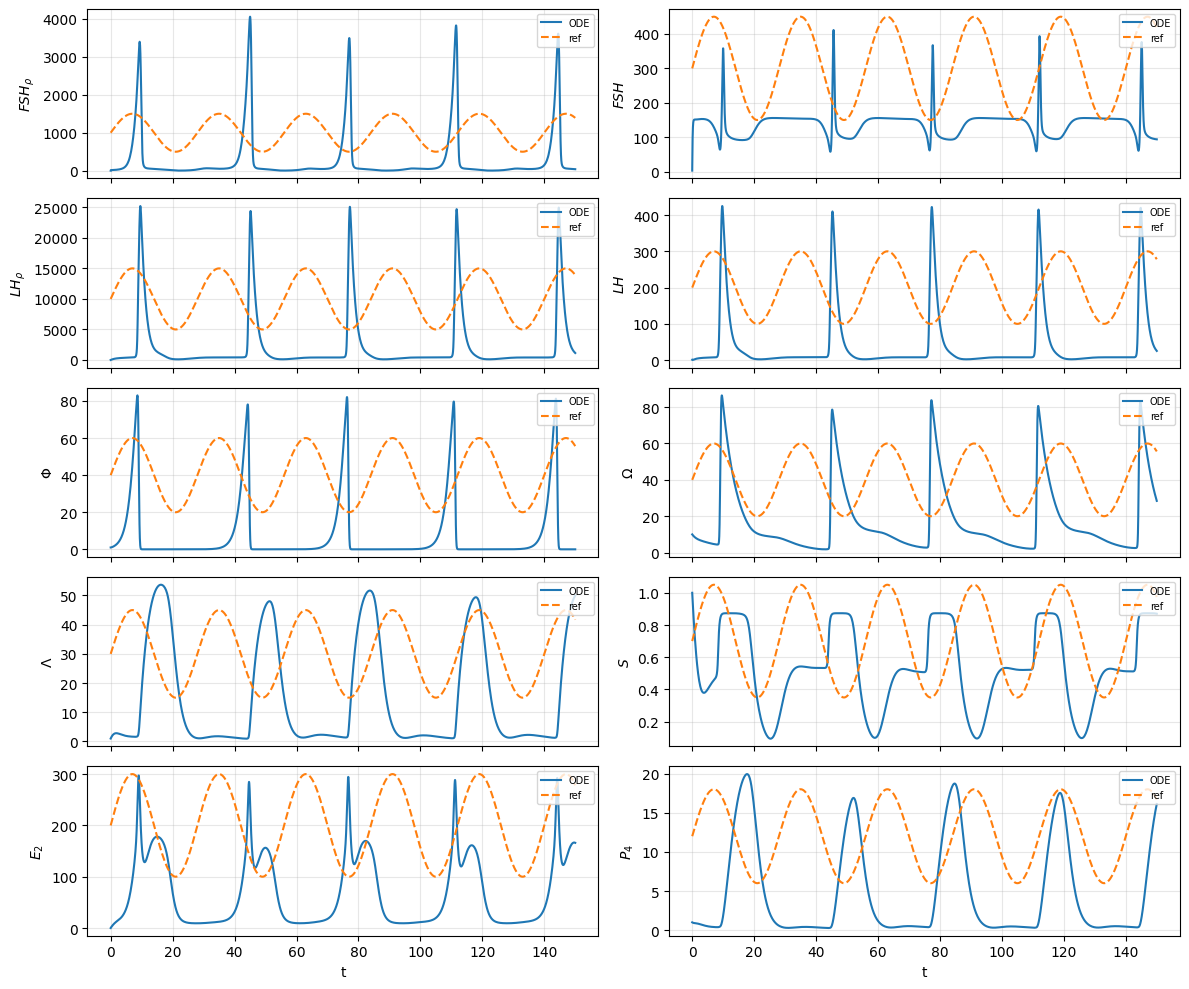

In [15]:
t_ref = np.linspace(0, t_end, 2000)

fig, axes = plt.subplots(5, 2, sharex=True, figsize=(12, 10))
axes = axes.ravel()

for i in range(10):
    axes[i].plot(t, x[:, i], label="ODE")
    axes[i].plot(t_ref, ref_funcs[i](t_ref), "--", label="ref")
    axes[i].set_ylabel(state_names[i])
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(fontsize=7, loc="upper right")

axes[-2].set_xlabel("t")
axes[-1].set_xlabel("t")
fig.tight_layout()
plt.show()

In [16]:
# Root-mean-square error between ODE solution and reference on the solver grid
print(f"{'State':<12}  {'RMSE':>12}")
print("-" * 27)
for i, name in enumerate(state_names):
    rmse = np.sqrt(np.mean((x[:, i] - ref_funcs[i](t)) ** 2))
    print(f"{name:<12}  {rmse:>12.4f}")

State                 RMSE
---------------------------
$FSH_\rho$       1316.3671
$FSH$             205.0048
$LH_\rho$       10043.3968
$LH$              187.2929
$\Phi$             39.7459
$\Omega$           34.6959
$\Lambda$          25.4407
$S$                 0.3627
$E_2$             140.8930
$P_4$              11.0040
